# Introduction to Data Science 2026

# Week 5

## Exercise 1 | Privacy and data protection

First, look up the [European Data Protection Regulation](http://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679&from=en) (“GDPR”). Note that Articles 1-99 start on p. 32 of the document. We will refer to the articles and their parts by, e.g., “Art 6 (1) a) GDPR” which means Article 6 (“Lawfulness of processing”), first paragraph, item a in the GDPR.

1. Valid Consent?

    Find a service you use to which you have given *consent* for the processing of your personal data (Art 6 (1) a) GDPR). Have a look at the privacy notices, policies, or settings of this service.

    - Are the basic legal conditions for this consent in your opinion in line with the new requirements and conditions set by the GDPR?

    - You should provide an answer with justification based on the GDPR, where you refer to specific articles and paragraphs.

2. Your Right to Access your Personal Data

    You have the right to know if personal data about you is processed by a controller. You also have the right to get access to, for example, the processing purposes, the data categories, data transfers, and duration of storage.

    - Find the relevant parts in GDPR and study your rights as a “data subject”.

    - File a right-to-access request with a data processing service of your choosing. Describe the mechanism that is put in place by the service to enable you to exercise this right (if any).

    - Whether you get a response or not, think about how well your rights as a data subject are respected in practice. Your answer should again refer to specific articles and paragraphs of the GDPR.

3. Anonymisation & Pseudonymisation

    - What is the difference between anonymisation and pseudonymisation of personal data?

**Submit your findings in a PDF file, just a short report is enough.**

I chose Instagram as the service I use. I read through their data policy and in short: they collect everything from single clicks to your phone number and WiFi signals. They have a long privacy policy telling what data they collect providing examples but they are very ambiguous at the same time. Meta also has a whole section about what is their legal basis on data collection and they mainly appeal on consent (Art 6 (1) a), legitimate interests (Art 6 (1) f), vital advantage (Art 6 (1) d), legal oblication (Art 6 (1) c) and public intrest (Art 6 (1) e). 

Consent is quite streight forward one, because I have (probably many times) given consent to the thousand things that I have not really read. According to instagram, I have been a user since 2014. I was only 19 years old. This raises an intresting question: "what age are you old enough to give consent to how your data is processed?". 

I think they are in line with the new requirements and they have written out every condition and article. I think meta has very good and expensive laywers who make sure that the data collecting is legal. The only complaint I'd have that it's not user friendly to read through the privacy policy nor do I think 99 % of users will ever read it or know what they consent to. 

Instagram notoriously informs me of my laws under GDPR as a data subject and have made practicing those laws relatively easy. You can quite easily and streightforwardly (after finding the right page) request to download or delete your data. The download was ready withing 30 minutes. As a result I get a zip file containing folders and html files. Each file has a description of what it contains; personal_data.html or synced_contacts.html. Some files are empty like device information. Overall the data I got back is very comprehensive and it includes my messags (not in encrypted format), my devices, my login information, my personal information and lot more. I wouldn't be suprised if that wasn't everything they store.

The difference between anonymisation and pseudonumisation is that if data is anonymisated it cannot be traced back to anyone or its original format. With pseudonumisation the data can be traced back to its original format where a person can be recognised. 

## Exercise 2 | Fairness-aware AI

This template generates data about the working hours and salaries of n=5000 people. The salary equals 100 x working hours plus/minus normal distributed noise. If you run the template, it produces an _hours_ vs _monthly salary_ scatter plot with gender=0 (men) in orange and gender=1 (women) in orange. The plot includes a trend line for each group, and an overall trend line for all data combined (in red). 

A linear regression model (see the next code cell) that only includes the working hours as a covariate *without* the protected characteristic (gender) should have slope close to 100.0.

In [181]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Simulating the data

In [182]:
#sample size n
n = 5000

# gender
gen = np.random.binomial(1, 0.5, size=n)

# work hours
hrs = np.random.binomial(60, 0.5, size=n)

# salary = 100 * hours + noise (std.deviation 10)
sal = hrs * np.random.normal(100, 10, size=n) 

# create a nice data frame
data = pd.DataFrame({"Gender": gen, "Hours": hrs, "Salary": sal})

### Scatterplot of the simulated data
Women samples (gender = 1) are shown with blue, men samples (gender = 0) are shown in orange.
Blue and orange lines are the trend lines of each group accordingly.
The overall trend line is shown in red.

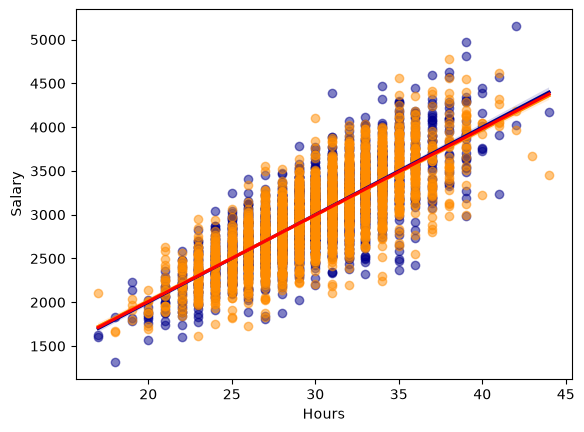

In [183]:
def plot_data(df):
    sns.regplot(x="Hours", y="Salary", data=df[df["Gender"]==1], color="darkBlue", scatter_kws={'alpha':0.5})

    sns.regplot(x="Hours", y="Salary", data=df[df["Gender"]==0], color="darkOrange", scatter_kws={'alpha':0.5})

    sns.regplot(x="Hours", y="Salary", data=df, marker="None", color="red")

    plt.show()

plot_data(data)

### Linear regression
Learn the overall regression model, which is what an algorithm with no access to the gender ("protected characteristic") would learn from the data.

In [184]:
def linear_regression(df):
    hours = df['Hours'].to_numpy()
    salary = df['Salary'].to_numpy()

    reg = LinearRegression().fit(hours.reshape(-1,1), salary.reshape(-1,1))

    # print out the slope: it should be close to 100.0 without learning the 'protected characteristic' (gender)
    print("slope: %.1f" % reg.coef_[0][0])

linear_regression(data)

def linear_regression_with_gender(df):
    X = df[["Hours", "Gender"]].to_numpy()
    y = df["Salary"].to_numpy()
    reg = LinearRegression().fit(X, y)
    print(f"Expected salary difference between men and women {round(reg.coef_[1], 3)} €")

linear_regression_with_gender(data)

slope: 98.8
Expected salary difference between men and women 7.336 €


### Task

Now edit the code to simulate each of the following scenarios:

a) the salary of women is reduced by 200 euros ("direct discrimination")



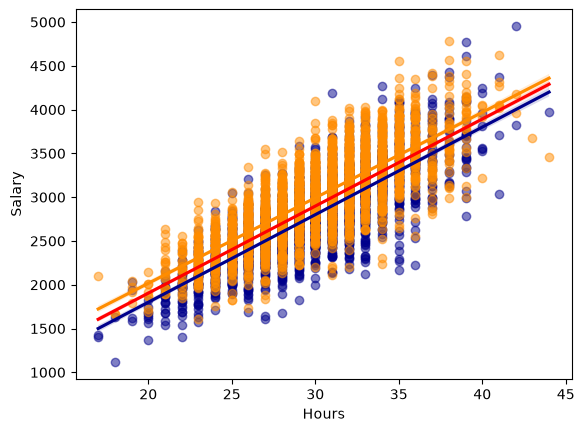

slope: 99.4
Expected salary difference between men and women -192.664 €


In [185]:
# print(data)

data_1 = data.copy()
data_1.loc[data_1["Gender"] == 1, "Salary"] -= 200

# print(data_1)
plot_data(data_1)
linear_regression(data_1)
linear_regression_with_gender(data_1)

b) the working hours of men are binomially distributed with parameters (60, 0.55) while the working hours of women are binomially distributed with parameters (60, 0.45), no changes in per-hour salary ("no discrimination")

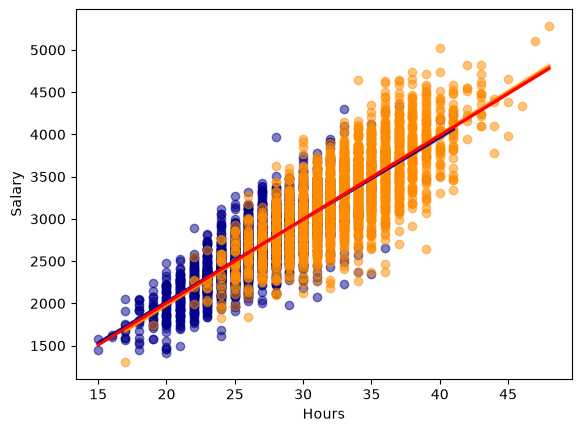

slope: 99.1
Expected salary difference between men and women 0.579 €


In [186]:
data_2 = data.copy()

wage = data["Salary"] / data["Hours"]

data_2.loc[data_2["Gender"] == 0, "Hours"] = np.random.binomial(60, 0.55, size=(data_2["Gender"] == 0).sum())
data_2.loc[data_2["Gender"] == 1, "Hours"] = np.random.binomial(60, 0.45, size=(data_2["Gender"] == 1).sum())
data_2["Salary"] = wage * data_2["Hours"] 

plot_data(data_2)
linear_regression(data_2)
linear_regression_with_gender(data_2)

c) both of the above changes at the same time ("indirect discrimination")

You should be able to demonstrate that the slope of the linear regression model is only changed in one of these scenarios.

Based on this experiment, answer the following questions:
1. In which of the scenarios the slope (coefficient) of the regression model changes?
2. How could you model the data in a way that enables you to detect indirect discrimination? _Hint_: Should you include the protected characteristic in the model or not?

To answer the second question, demonstrate your solution by building a regression model and interpreting the estimated coefficients.



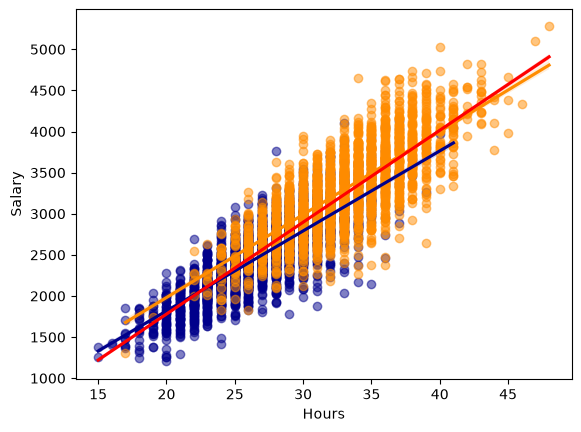

slope: 111.7
Expected salary difference between men and women -199.421 €


In [187]:
data_3 = data_2.copy()

data_3.loc[data_3["Gender"] == 1, "Salary"] -= 200

plot_data(data_3)
linear_regression(data_3)
linear_regression_with_gender(data_3)